<div class="alert alert-block alert-info">  
<h1><center><strong>Importing Python libraries</strong></center></h1>


   
        
</div>

In [1]:
import pandas as pd
import numpy as np  
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn import preprocessing
from keras.models import Sequential
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from prettytable import PrettyTable
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
import time
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

<div class="alert alert-block alert-danger">  
<h2><center><strong>Loading the data 📁 📂</strong></center></h2>
        
</div>

In [2]:
data = pd.read_csv("home-credit-default-risk/application_train.csv")

In [3]:
PATH='home-credit-default-risk'
application_train = pd.read_csv(PATH+"/application_train.csv")
application_test = pd.read_csv(PATH+"/application_test.csv")
bureau = pd.read_csv(PATH+"/bureau.csv")
bureau_balance = pd.read_csv(PATH+"/bureau_balance.csv")
credit_card_balance = pd.read_csv(PATH+"/credit_card_balance.csv")
installments_payments = pd.read_csv(PATH+"/installments_payments.csv")
previous_application = pd.read_csv(PATH+"/previous_application.csv")
POS_CASH_balance = pd.read_csv(PATH+"/POS_CASH_balance.csv")

<div class="alert alert-block alert-danger">  
<h2><center><strong>Exploratory data analysis 🔎 📊</strong></center></h2>
        
</div>

#### Five top records of data

In [4]:
data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


#### Five last records of data

In [5]:
data.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


#### Coloumns/features in data

In [6]:
data.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

#### Length of data

In [7]:
print('lenght of data is', len(data))

lenght of data is 307511


#### Shape of data

In [8]:
data.shape

(307511, 122)

#### Data information

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


#### Data types of all coloumns

In [10]:
data.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

#### Checking Null values / missing values

In [11]:
np.sum(data.isnull().any(axis=1))

298909

#### Counts of missing values in each column

In [12]:
data.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

#### Rows and columns in the dataset

In [13]:
print('Count of columns in the data is:  ', len(data.columns))

Count of columns in the data is:   122


In [14]:
print('Count of rows in the data is:  ', len(data))

Count of rows in the data is:   307511


#### Data Description

In [15]:
data.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## Univariate Analysis 

#### Numeric features distrubution 

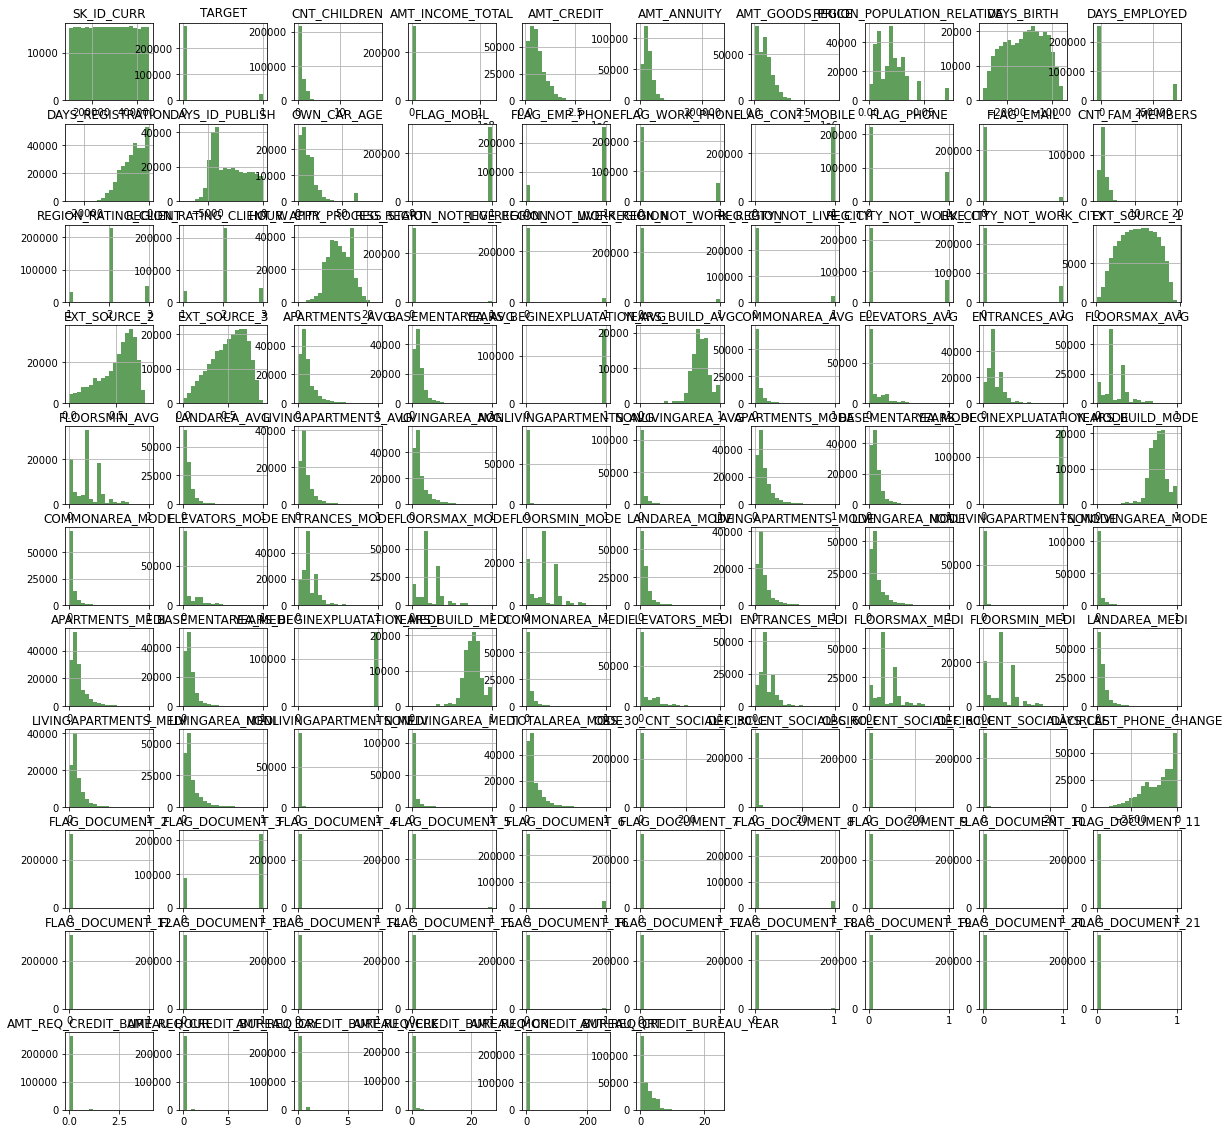

In [16]:
data.hist(figsize=(20,20),bins = 20, color="#107009AA")
plt.title("Numeric Features Distribution")
plt.show()

### As we can see above, there are the values ranges of all features. Every feature have different distribution of values. To understand the features better and deeper, we are going to look at each one separately. 

### TARGET distribution

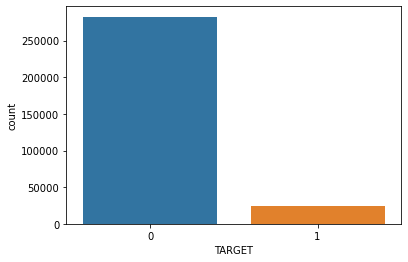

In [17]:
sns.countplot(data= data, x = "TARGET")
plt.show()

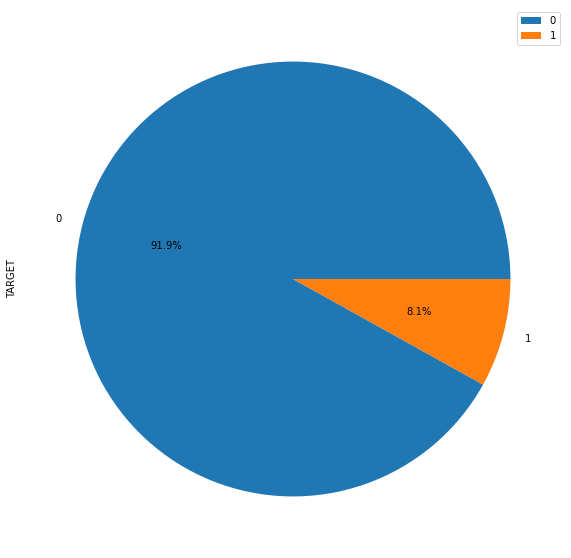

In [18]:
data["TARGET"].value_counts().head(10).plot(kind = 'pie', autopct='%1.1f%%', figsize=(10, 10)).legend()

In [19]:
#Deatils of the other data files 
print("application_train -  rows:",application_train.shape[0]," columns:", application_train.shape[1])
print("application_test -  rows:",application_test.shape[0]," columns:", application_test.shape[1])
print("bureau -  rows:",bureau.shape[0]," columns:", bureau.shape[1])
print("bureau_balance -  rows:",bureau_balance.shape[0]," columns:", bureau_balance.shape[1])
print("credit_card_balance -  rows:",credit_card_balance.shape[0]," columns:", credit_card_balance.shape[1])
print("installments_payments -  rows:",installments_payments.shape[0]," columns:", installments_payments.shape[1])
print("previous_application -  rows:",previous_application.shape[0]," columns:", previous_application.shape[1])
print("POS_CASH_balance -  rows:",POS_CASH_balance.shape[0]," columns:", POS_CASH_balance.shape[1])

application_train -  rows: 307511  columns: 122
application_test -  rows: 48744  columns: 121
bureau -  rows: 1716428  columns: 17
bureau_balance -  rows: 27299925  columns: 3
credit_card_balance -  rows: 3840312  columns: 23
installments_payments -  rows: 13605401  columns: 8
previous_application -  rows: 1670214  columns: 37
POS_CASH_balance -  rows: 10001358  columns: 8


### Checking categorical type columns in the data 

In [20]:
data.select_dtypes(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,M,N,N,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,Sales staff,THURSDAY,Services,reg oper account,block of flats,"Stone, brick",No
307507,Cash loans,F,N,Y,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,NaN,MONDAY,XNA,reg oper account,block of flats,"Stone, brick",No
307508,Cash loans,F,N,Y,Unaccompanied,Working,Higher education,Separated,House / apartment,Managers,THURSDAY,School,reg oper account,block of flats,Panel,No
307509,Cash loans,F,N,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 1,NaN,block of flats,"Stone, brick",No


### Encoding these categorical features into numeric type

In [21]:
categorical_columns = data.select_dtypes(['object']).columns
label_encoder = preprocessing.LabelEncoder()
for col in data[categorical_columns]:
    data[col]=data[col].astype(str)
    data[col]=label_encoder.fit_transform(data[col])

As we can see that, we encoded the categorical features into numeric form so we can use them in the models.

<div class="alert alert-block alert-danger">  
<h1><center><strong>Data Preparation 📝</strong></center></h1>


   
        
</div>

### Deleting the duplicate rows

In [22]:
current=len(data)
print('Rows of data before Delecting ', current)

Rows of data before Delecting  307511


In [23]:
data=data.drop_duplicates()

In [24]:
now=len(data)
print('Rows of data before Delecting ', now)

Rows of data before Delecting  307511


In [25]:
diff=current-now
print('Duplicated rows deleted ', diff)

Duplicated rows deleted  0


### Missing value Treatment

In [27]:
data.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [28]:
data.isnull().sum().sum()/len(data)

27.277378695396262

There are almost 28% missing values in the data. Most of them contains almost more than 80% missing values. For now going to fill NaN values with 0.

In [31]:
data=data.fillna(0)

Now we dont have any any missing values in the features.

<b> <h3> Inputs : </h3></b>  Inputs are the data features that we feed into model like in this project department, region,education,gender are the inputs. 

<b> <h3> Training Data </h3></b>  We use training data when we train the models. We feed train data to tensorflow model so that model can learn from the data.

<b> <h3> Testing Data </h3></b>  We use testing data after training the model. We use this data to evalaute the performance that how the model perform after training. So in this way first we get predictions from the trained model without giving the Target and then we compare the true Target with predictions and get the performance of the model.

####  Separating input feature and label

In [76]:
X=data.drop(columns=['TARGET'])
y=data['TARGET']

<div class="alert alert-block alert-info">  
<h1><center><strong>Feature Selection</strong></center></h1>
        
</div>

### Univariate feature selection
- using f_classif technique to extrcat the most useful features from the data

In [78]:
FCF_M= SelectKBest(f_classif, k=50)
FCF_M.fit(X, y)
FCF_features = FCF_M.transform(X)

In [79]:
feature_names = list(X.columns[FCF_M.get_support(indices=True)])
FCF_features=pd.DataFrame(FCF_features)
FCF_features.columns=feature_names
FCF_features.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,FLOORSMAX_MEDI,FLOORSMIN_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3
0,0.0,1.0,0.0,406597.5,351000.0,7.0,4.0,1.0,0.018801,-9461.0,...,0.0833,0.1250,0.0,0.0149,5.0,0.0,2.0,2.0,-1134.0,1.0
1,0.0,0.0,0.0,1293502.5,1129500.0,4.0,1.0,1.0,0.003541,-16765.0,...,0.2917,0.3333,0.0,0.0714,0.0,0.0,0.0,0.0,-828.0,1.0
2,1.0,1.0,0.0,135000.0,135000.0,7.0,4.0,1.0,0.010032,-19046.0,...,0.0000,0.0000,1.0,0.0000,7.0,2.0,0.0,0.0,-815.0,0.0
3,0.0,0.0,0.0,312682.5,297000.0,7.0,4.0,1.0,0.008019,-19005.0,...,0.0000,0.0000,1.0,0.0000,7.0,2.0,0.0,0.0,-617.0,1.0
4,0.0,1.0,0.0,513000.0,513000.0,7.0,4.0,1.0,0.028663,-19932.0,...,0.0000,0.0000,1.0,0.0000,7.0,2.0,0.0,0.0,-1106.0,0.0


In [80]:
FCF_features=pd.DataFrame(FCF_features)
FCF_features.shape[1]  #Features count

50

### Univariate feature selection
- using chi2 technique to extrcat the most useful features from the data

In [84]:
X[X< 0] = 0
C_M= SelectKBest(chi2, k=50)
C_M.fit(X, y)
C_features = C_M.transform(X)

In [85]:
feature_names = list(X.columns[C_M.get_support(indices=True)])
C_features=pd.DataFrame(C_features)
C_features.columns=feature_names
C_features.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_6,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_MON
0,100002.0,0.0,1.0,0.0,202500.0,406597.5,24700.5,351000.0,7.0,4.0,...,5.0,0.0,2.0,2.0,2.0,2.0,1.0,0.0,0.0,0.0
1,100003.0,0.0,0.0,0.0,270000.0,1293502.5,35698.5,1129500.0,4.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,100004.0,1.0,1.0,0.0,67500.0,135000.0,6750.0,135000.0,7.0,4.0,...,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006.0,0.0,0.0,0.0,135000.0,312682.5,29686.5,297000.0,7.0,4.0,...,7.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0
4,100007.0,0.0,1.0,0.0,121500.0,513000.0,21865.5,513000.0,7.0,4.0,...,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
C_features=pd.DataFrame(C_features)
C_features.shape[1]  #Features count

50

- We are going to combine all the features that are selected using differenet techniques 

In [87]:
Hybrid_Features=pd.concat([FCF_features, C_features], axis=1)
#drop all those features 
Hybrid_Features1 = Hybrid_Features.loc[:,~Hybrid_Features.columns.duplicated()]

In [88]:
Hybrid_Features1.shape[1]  #Features count

64

<div class="alert alert-block alert-info">  
<h2><center><strong> Model building - Logistic Regression</strong></center></h2>
        
</div>

#### Separating the 70% data for training data and 30% for testing data

As we prepared all the data, now we are separating/splitting the all data into training data and testing data.
- 70% data will be used in the training 
- 30% data will be used to test the performance of the model.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(Hybrid_Features1, y, test_size=0.3, random_state=2)

#### Training the Logistic Regression Model

In [47]:
LR=LogisticRegression()
LR= LR.fit(X_train , y_train)
LR

LogisticRegression()

## Evaluation of Trained model on test data

#### Accuracy

In [48]:
print('Test set\n  Accuracy: {:0.2f}'.format(LR.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


#### Getting prediction of the test data and then we will compare the true Target/classes of the data with predictions

In [49]:
y_pred = LR.predict(X_test) #getting predictions on the trained model

#### Precision Score on test data
- Precision measure the number of positive class predictions that actually belong to the positive class

In [50]:
print('Precision',round(f1_score(y_test, y_pred, average='micro'),3),'%')

Precision 0.923 %


#### Recall Score on test data
- Recall measures the number of positive class predictions made out of all positive records in the dataset

In [51]:
print('Recall',round(recall_score(y_test, y_pred, average='micro'),4),'%')

Recall 0.9227 %


#### F1 Measure Score on test data
- F-Measure is the average of the precision and recall. 

In [52]:
print('F1',round(f1_score(y_test, y_pred, average='micro'),2),'%')

F1 0.92 %


<div class="alert alert-block alert-info">  
<h2><center><strong> Model building - Bagging and Boosting</strong></center></h2>
        
</div>

<div class="alert alert-block alert-success">  
<h4>Decision Tree Model</h4>
        
</div>

In [54]:
DT=DecisionTreeClassifier()
DT= DT.fit(X_train , y_train)
DT

DecisionTreeClassifier()

In [55]:
dt=DT.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(DT.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.85


<div class="alert alert-block alert-success">  
<h4>Random Forest Classifier Model</h4>
        
</div>

In [56]:
RN=RandomForestClassifier()
RN= RN.fit(X_train , y_train)
RN

RandomForestClassifier()

In [57]:
rn=RN.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(RN.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


<div class="alert alert-block alert-success">  
<h4>Bagging Classifier Model</h4>
        
</div>

In [58]:
BC=BaggingClassifier()
BC= BC.fit(X_train , y_train)
BC

BaggingClassifier()

In [59]:
bc=BC.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(BC.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


<div class="alert alert-block alert-success">  
<h4>XGB Classifierr Model</h4>
        
</div>

In [60]:
XG=XGBClassifier(verbosity = 0)
XG= XG.fit(X_train , y_train)
XG

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [61]:
xg=XG.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(XG.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


<div class="alert alert-block alert-success">  
<h4>AdaBoost Classifier Model</h4>
        
</div>

In [62]:
AD=AdaBoostClassifier()
AD= AD.fit(X_train , y_train)
AD

AdaBoostClassifier()

In [63]:
ad=AD.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(AD.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


<div class="alert alert-block alert-success">  
<h4>Gradient Boosting Classifier Model</h4>
        
</div>

In [64]:
GB=GradientBoostingClassifier()
GB= GB.fit(X_train , y_train)
GB

GradientBoostingClassifier()

In [65]:
gb=GB.score(X_test, y_test)
print('Test set\n  Accuracy: {:0.2f}'.format(GB.score(X_test, y_test))) #the accuracy of the model on test data is given below

Test set
  Accuracy: 0.92


<div class="alert alert-block alert-danger">  
<h1><center><strong>Comparison of Bagging and Boosting Models</strong></center></h1>
        
</div>

In [66]:
x = PrettyTable()
print('\n')
x.field_names = ["Model", "Accuracy"]
x.add_row(["Decision Tree Model", round(dt,2)])
x.add_row(["Random Forest Classifier Model", round(rn,2)])
x.add_row(["Bagging Classifier Model", round(bc,2)])
x.add_row(["XGB Classifierr Model", round(xg,2)])
x.add_row(["AdaBoost Classifier Model", round(ad,2)])
x.add_row(["Gradient Boosting Classifier Model", round(gb,2)])

print(x)
print('\n')



+------------------------------------+----------+
|               Model                | Accuracy |
+------------------------------------+----------+
|        Decision Tree Model         |   0.85   |
|   Random Forest Classifier Model   |   0.92   |
|      Bagging Classifier Model      |   0.92   |
|       XGB Classifierr Model        |   0.92   |
|     AdaBoost Classifier Model      |   0.92   |
| Gradient Boosting Classifier Model |   0.92   |
+------------------------------------+----------+




XGBoost and Gradient Decent models are giving highest accuracy with 92% which is good. But Decision tree model is lower than others with only 85% accuracy. Random forest,Bagging and Adaboost also performed well with 92% accuracy. 

<div class="alert alert-block alert-info">  
<h1><center><strong>Actionable Insights & Recommendations 📝</strong></center></h1>
    <p><li>We used the Credit risk dataset and explored the data with different ways.</li>
        <li>According to the data, percentage of loan repayed is higher among the people who paid the payments.</li>
        <li>The ratio of not repayed increases with previous year rating which is quite obvious.</li>
          <li>Ratio doesn't vary much with the ages of people.</li>
        <li>It is recommneded to manage the data of credit risk with all checkpoints like previous year rating is important but it contains a lot of missing values. </li>
        <li>We trained the model with train data but the results were  satisfactory.</li>
        <li>We trained the models with Bagging and Boosting and got the good results. </li>
        <li>After that we applied the grid search and random search techniques to train the models but the results were almost same. </li>
        <li>We evaluated the model with different evaluation measures to check the performance on all techniques that we applied. </li>
           <li>XGBoost Model gave us the good results with 92% as well as took very less time as compare to other models.  </li>
         <li>Bank relevant department can use the final model of XGBoost and can feed the previous record of the people and can get prediction that they are going to repay or not</li>
        </p>
</div>